In [35]:
import os
import numpy as np
import pandas as pd
import librosa
import noisereduce as nr
from scipy import signal
from tqdm import tqdm
import matplotlib.pyplot as plt

In [24]:
class PreprocessingPipeline:

    def __init__(
        self,
        p_chirp_data,
        p_temp_corr,
        path_2_audio_files,
        feature_save_dir,
        freq_corrected_save_dir,        
        start=10,
        cutoff=8000,
        padding_length=10955,
        nyq_freq = 2250,
        **spec_kwargs
    ):

        self.p_chirp_data = p_chirp_data
        self.p_temp_corr = p_temp_corr
        self.path_2_audio_files = path_2_audio_files
        self.feature_save_dir = feature_save_dir
        self.freq_corrected_save_dir = freq_corrected_save_dir
        self.start = start
        self.cutoff = cutoff
        self.padding_length = padding_length
        self.nyq_freq = nyq_freq
        self.spec_kwargs = spec_kwargs

        self.df = self.reader()
        self.ch_2_time_scale, self.ch_2_freq_scale = self.load_temperature_correction()

    def reader(self):
        d1 = pd.read_csv(self.p_chirp_data)
        d2 = pd.read_csv(self.p_temp_corr)
        return d1[d1["Chirp"].isin(d2["chirp"])]
        
    
    def chirp_data(self):
        df = self.df[["Chirp", "Start", "End", "Audio"]]
        data = [(ch, s, e, o) for ch, s, e, o in df.to_records(index = False)]
        return data

    def audio_chirp_start_end(self):
        audio_2_data = {}
        for chirp, start, end, audio in self.chirp_data():
            if audio not in audio_2_data:
                audio_2_data[audio] = [(chirp, start, end)]
            else:
                audio_2_data[audio].append((chirp, start, end))
        return audio_2_data

    def load_audio(self, file_name):
        signal_data, sr = librosa.load(self.path_2_audio_files + file_name, sr=None, offset=self.start)
        reduced_noise = nr.reduce_noise(y=signal_data, sr=sr)
        filtered = self.butter_lowpass_filter(reduced_noise, self.cutoff, self.nyq_freq)
        normalised = filtered / np.abs(filtered).max()
        return normalised

    def butter_lowpass(self, cutoff, nyq_freq, order=4):
        normal_cutoff = float(cutoff) / nyq_freq
        b, a = signal.butter(order, normal_cutoff, btype="lowpass")
        return b, a

    def butter_lowpass_filter(self, data, cutoff_freq, nyq_freq, order=4):
        b, a = self.butter_lowpass(cutoff_freq, nyq_freq, order=order)
        return signal.filtfilt(b, a, data)

    def pad_signal(self, signal):
        length = len(signal)
        if length < self.padding_length:
            dx = self.padding_length - length
            left = dx // 2
            right = dx - left
            return np.pad(signal, (left, right), mode = "constant", constant_values = 0)
        return signal_data

    def extract_spectrogram(self, signal_data):
        return librosa.feature.melspectrogram(y=signal_data, **self.spec_kwargs)

    def save_feature(self, feature, save_dir, file_name):
        save_path = os.path.join(save_dir, file_name + ".npy")
        np.save(save_path, feature)

    def load_temperature_correction(self):
        dt = pd.read_csv(self.p_temp_corr)
        ch_ts_df = dt[["chirp", "time_scale_factor"]]
        ch_fs_df = dt[["chirp", "freq_scale_factor"]]
        ch2ts = {ch: scale for ch, scale in ch_ts_df.to_records(index=False)}
        ch2fs = {ch: scale for ch, scale in ch_fs_df.to_records(index=False)}
        return ch2ts, ch2fs

    def chirp_duration_correction(self, factor, signal_data):
        return librosa.effects.time_stretch(signal_data, rate=factor)

    def chirp_frequency_correction(self, factor, signal_data):
        return librosa.resample(signal_data,
                                orig_sr=self.spec_kwargs["sr"], 
                                target_sr=int(self.spec_kwargs["sr"] * factor)
                               )

    def process(self):

        audio_2_data = self.audio_chirp_start_end()
        for audio_file, data in tqdm(audio_2_data.items()):
            signal_data = self.load_audio(audio_file)
            for frame_name, start, end in data:
                time_factor = self.ch_2_time_scale[frame_name]
                freq_factor = self.ch_2_freq_scale[frame_name]
                frame_signal = signal_data[start - 400:end + 400]

                # Duration correction only
                duration_corrected = self.chirp_duration_correction(time_factor, frame_signal)
                duration_padded = self.pad_signal(duration_corrected)
                duration_spectrogram = self.extract_spectrogram(duration_padded)

                # Duration + frequency correction
                frequency_corrected = self.chirp_frequency_correction(freq_factor, duration_corrected)
                frequency_padded = self.pad_signal(frequency_corrected)
                frequency_spectrogram = self.extract_spectrogram(frequency_padded)
                self.save_feature(duration_spectrogram, self.feature_save_dir, frame_name)
                self.save_feature(frequency_spectrogram, self.freq_corrected_save_dir, frame_name)


In [27]:
if __name__ == "__main__":

    WINDOW_LENGTH = 1024
    HOPE_LENGTH = 256
    NUMBER_MELS = 128
    RESAMPLE_RATE = 44100
    POWER = 1
    F_MIN = 4000
    F_MAX = 8000
    START = 10
    PADDING_LENGTH = 10955
    
    PARAMETERS = {"n_fft":WINDOW_LENGTH,
                  "hop_length":HOPE_LENGTH,
                  "n_mels":NUMBER_MELS,
                  "sr":RESAMPLE_RATE,
                  "power":POWER,
                  "fmin":F_MIN,
                  "fmax":F_MAX
                 }

    pipeline = PreprocessingPipeline(
        p_chirp_data = "../chirp_index_extraction/chirp_data.csv",
        p_temp_corr = "corrected_temperature_data.csv",
        path_2_audio_files = "../audio_files/",
        feature_save_dir = "5_arr_time_corrected/",
        freq_corrected_save_dir = "5_arr_time_freq_corrected/",
        start = START,
        cutoff = F_MAX,
        padding_length = PADDING_LENGTH,
        nyq_freq = RESAMPLE_RATE/2,
        **PARAMETERS
    )

    pipeline.process()

100%|█████████████████████████████████████████████| 7/7 [00:22<00:00,  3.18s/it]


In [29]:
f = "5_arr_time_corrected/"

In [37]:
specs = os.listdir(f)
spec = np.load(f+specs[1])

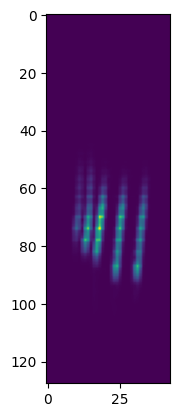

In [38]:
plt.imshow(spec)